# Eksplorasi Analisis & Prediksi Harga Pangan XGBoost
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi XGBoost untuk seluruh subkategori komoditas pangan nasional (level 2) berdasarkan data dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Collecting**: Mengambil data harga dari API Bank Indonesia untuk 21 subkategori komoditas pangan (level 2) dengan retry logic dan local caching.
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan stasioneritas (ADF Test) untuk seluruh subkategori.
3. **Data Preprocessing & Modeling Pipeline**: Pembagian data temporal (train/test split), imputasi data secara independen (mencegah data leakage), dan penyetelan hyperparameter XGBoost.
4. **Model Training (XGBoost)**: Melatih model XGBoost dengan GridSearchCV temporal dan early stopping.
5. **Model Evaluation**: Mengevaluasi hasil prediksi untuk seluruh subkategori komoditas pangan menggunakan metrik visual dan statistik (MAE, RMSE, MAPE, R2).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Menyembunyikan warning
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Data Collecting
Kami mengunduh data harian dari portal Pusat Informasi Harga Pangan Strategis (PIHPS) Bank Indonesia untuk 21 subkategori bahan pokok (level 2) yang berada di bawah 10 kategori utama berikut:
- `cat_1` (Beras)
- `cat_2` (Daging Ayam)
- `cat_3` (Daging Sapi)
- `cat_4` (Telur Ayam)
- `cat_5` (Bawang Merah)
- `cat_6` (Bawang Putih)
- `cat_7` (Cabai Merah)
- `cat_8` (Cabai Rawit)
- `cat_9` (Minyak Goreng)
- `cat_10` (Gula Pasir)

Rentang waktu yang digunakan adalah dari 2024-01-01 hingga 2026-05-24. Untuk menjamin keandalan sistem, diimplementasikan mekanisme **retry logic** dengan *exponential backoff* dan **local caching** menggunakan file CSV.


In [2]:
# List kategori komoditas berdasarkan request
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

json_path = "dataset/commodity_history.json"
cache_file = "raw_market_prices_subcategory_cache.csv"

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    import json
    print(f"Membaca data dari local dataset '{json_path}'...")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File dataset tidak ditemukan di: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
        
    raw_data_list = []
    
    current_category = None
    # Filter dan strukturkan data agar sesuai format wide dataframe sebelumnya
    for item in json_data["data"]:
        level = item.get("level")
        name = item.get("name")
        if level == 1:
            current_category = name
        elif level == 2:
            if current_category in categories.values():
                row_dict = {"Category": current_category, "Subcategory": name}
                
                # Ambil semua data tanggal (key format DD/MM/YYYY)
                for key, value in item.items():
                    if "/" in key and len(key.split("/")) == 3:
                        row_dict[key] = value
                        
                raw_data_list.append(row_dict)
                print(f"Berhasil memuat data untuk subkategori: {name} (Kategori: {current_category})")
            
    df_raw = pd.DataFrame(raw_data_list)
    
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari dataset JSON. Periksa format data.")

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()


Menemukan file cache lokal 'raw_market_prices_subcategory_cache.csv'. Membaca data cache...

Dimensi data mentah: (21, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras Kualitas Bawah I,"13,550","13,650","13,650","13,650","13,650","13,650","13,650","13,650",...,"14,550","14,100","14,100","14,550","14,550","14,550","14,600","14,600","14,100","14,100"
1,Beras,Beras Kualitas Bawah II,"13,200","13,400","13,400","13,400","13,400","13,400","13,400","13,400",...,"14,550","14,600","14,600","14,550","14,550","14,450","14,450","14,450","14,600","14,600"
2,Beras,Beras Kualitas Medium I,"14,650","14,750","14,750","14,750","14,750","14,750","14,750","14,750",...,"16,150","15,750","15,750","16,150","16,150","16,150","16,150","16,150","15,750","15,750"
3,Beras,Beras Kualitas Medium II,"14,400","14,550","14,600","14,600","14,550","14,550","14,550","14,600",...,"16,000","15,450","15,450","16,000","16,000","16,000","16,000","16,000","15,450","15,450"
4,Beras,Beras Kualitas Super I,"15,850","16,050","16,050","16,050","16,050","16,050","16,050","16,050",...,"17,400","16,850","16,850","17,400","17,400","17,400","17,450","17,450","16,850","16,850"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari seluruh subkategori komoditas pangan.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk seluruh subkategori guna mengetahui karakteristik tren.


In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Subcategory", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Subkategori:")
print(df_tidy.groupby(["Category", "Subcategory"])["Price"].describe())


Dimensi data bersih: (18375, 4)

Statistik Deskriptif Subkategori:
                                               count           mean  \
Category      Subcategory                                             
Bawang Merah  Bawang Merah Ukuran Sedang       875.0   42839.828571   
Bawang Putih  Bawang Putih Ukuran Sedang       875.0   42381.942857   
Beras         Beras Kualitas Bawah I           875.0   14263.028571   
              Beras Kualitas Bawah II          875.0   14096.685714   
              Beras Kualitas Medium I          875.0   15621.485714   
              Beras Kualitas Medium II         875.0   15480.000000   
              Beras Kualitas Super I           875.0   16918.228571   
              Beras Kualitas Super II          875.0   16437.828571   
Cabai Merah   Cabai Merah Besar                875.0   51157.542857   
              Cabai Merah Keriting             875.0   51412.171429   
Cabai Rawit   Cabai Rawit Hijau                875.0   49954.857143   
          

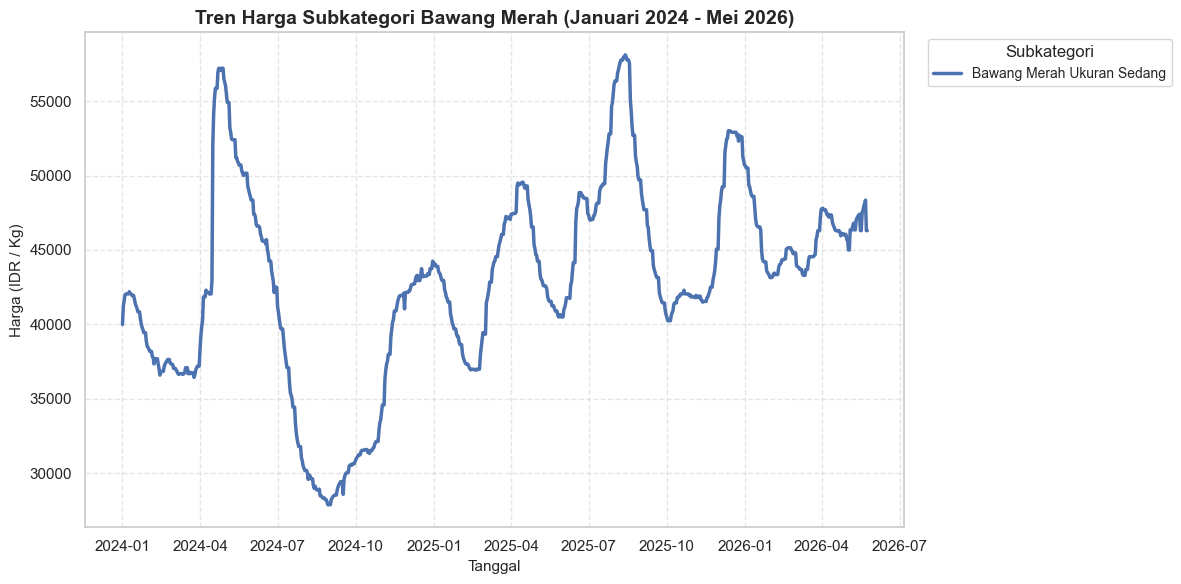

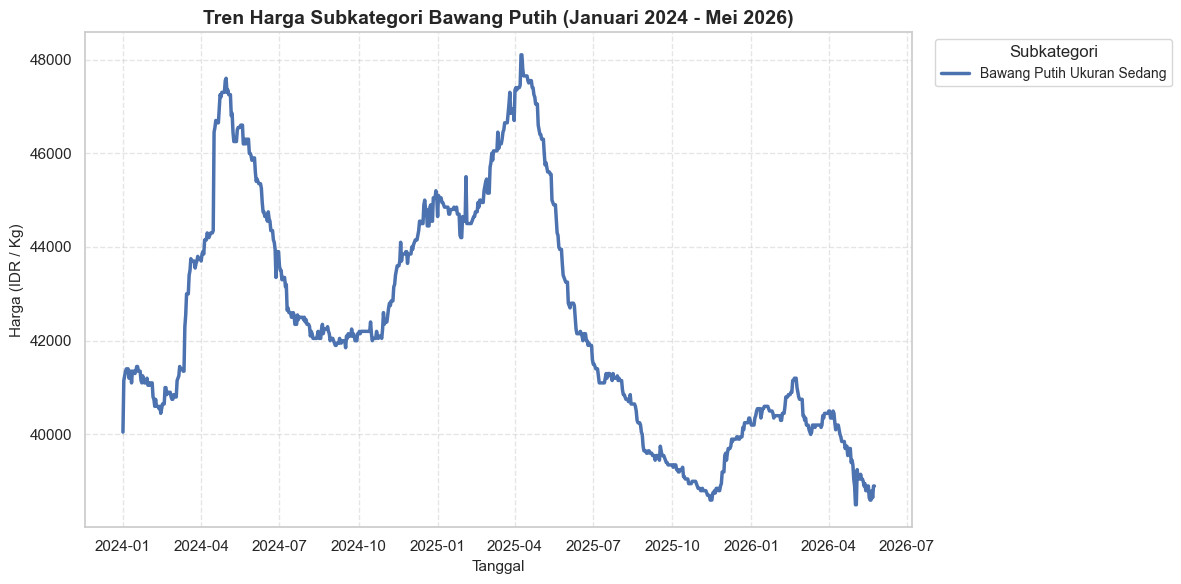

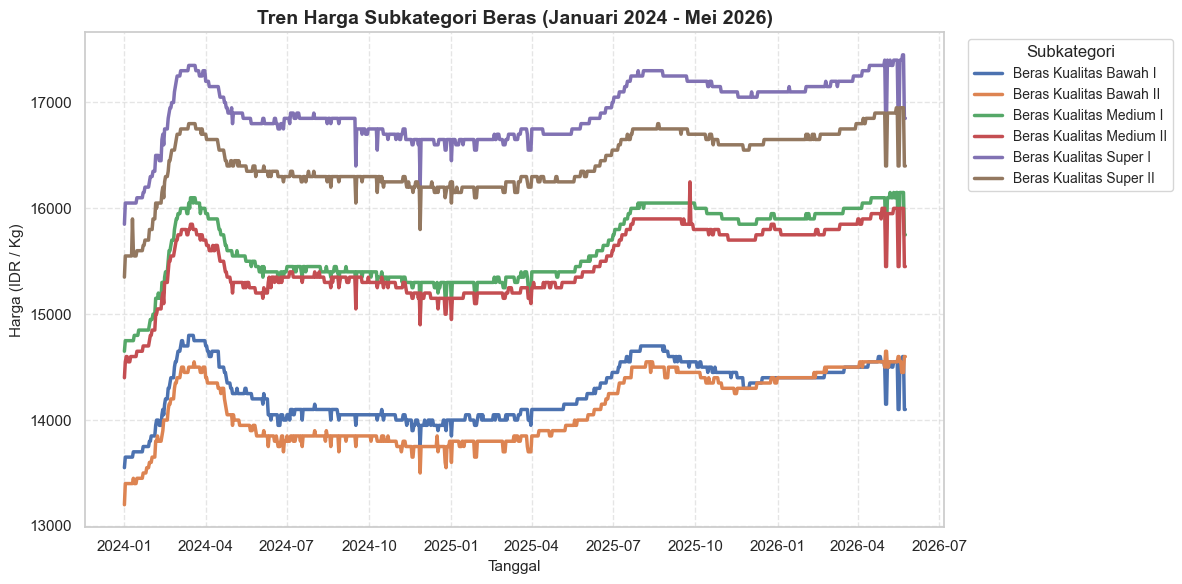

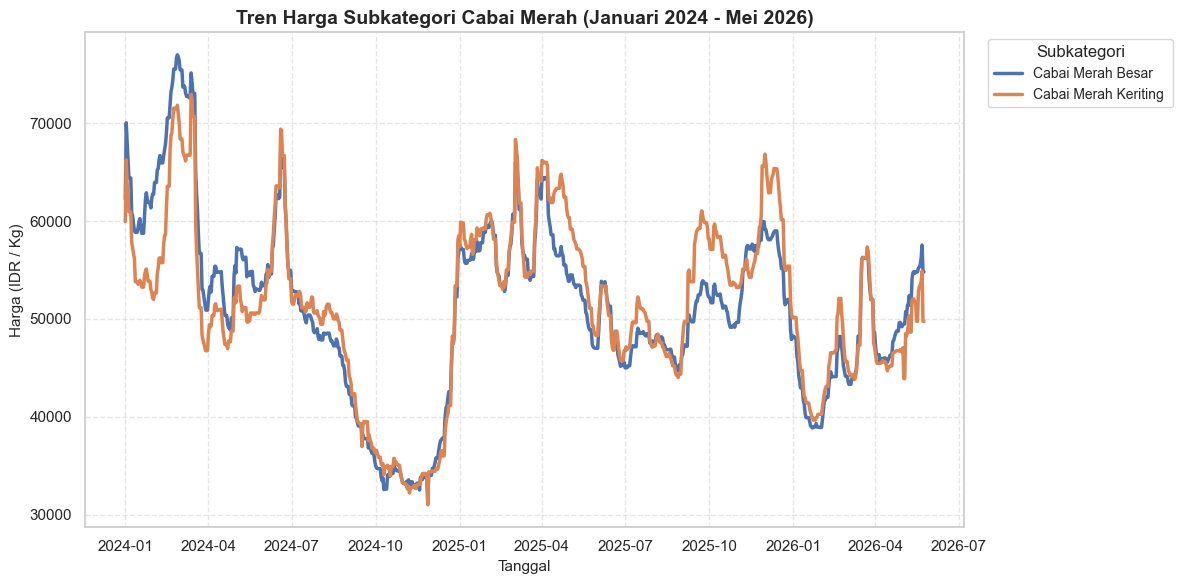

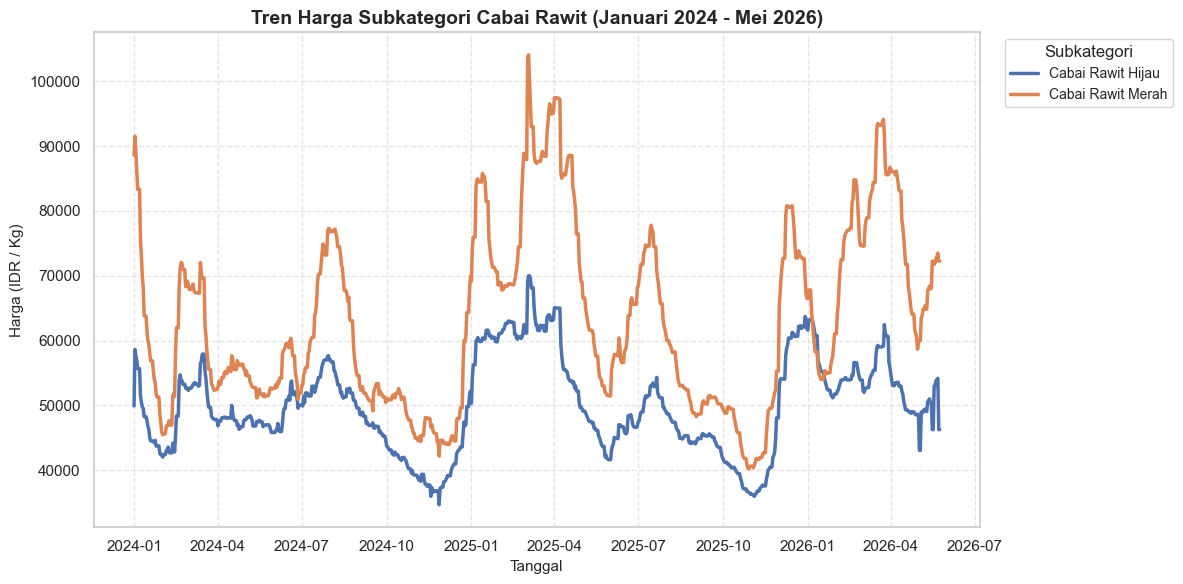

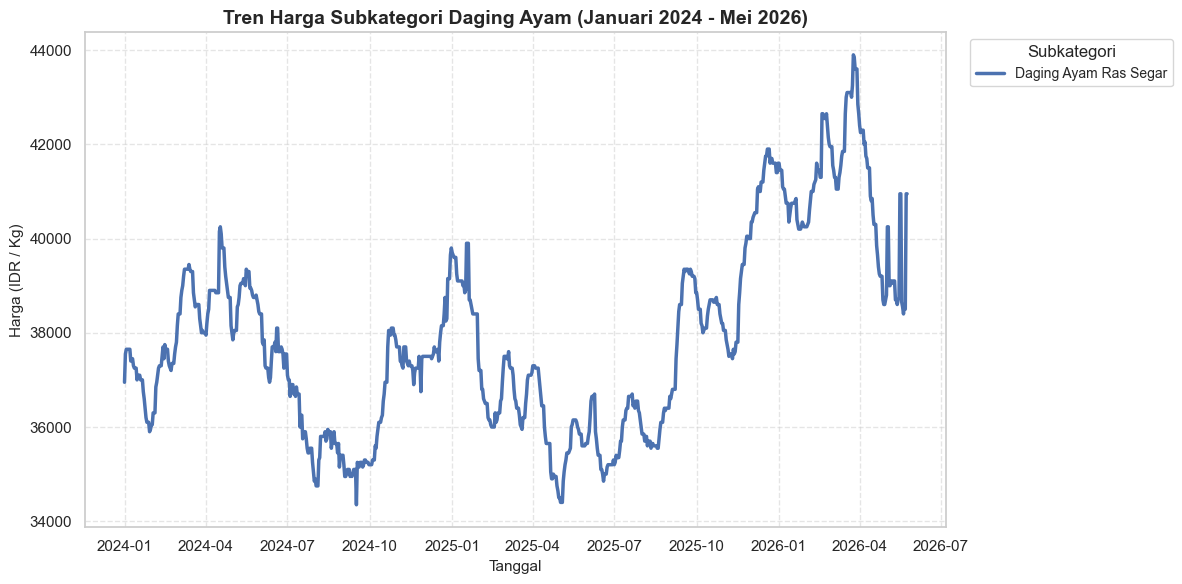

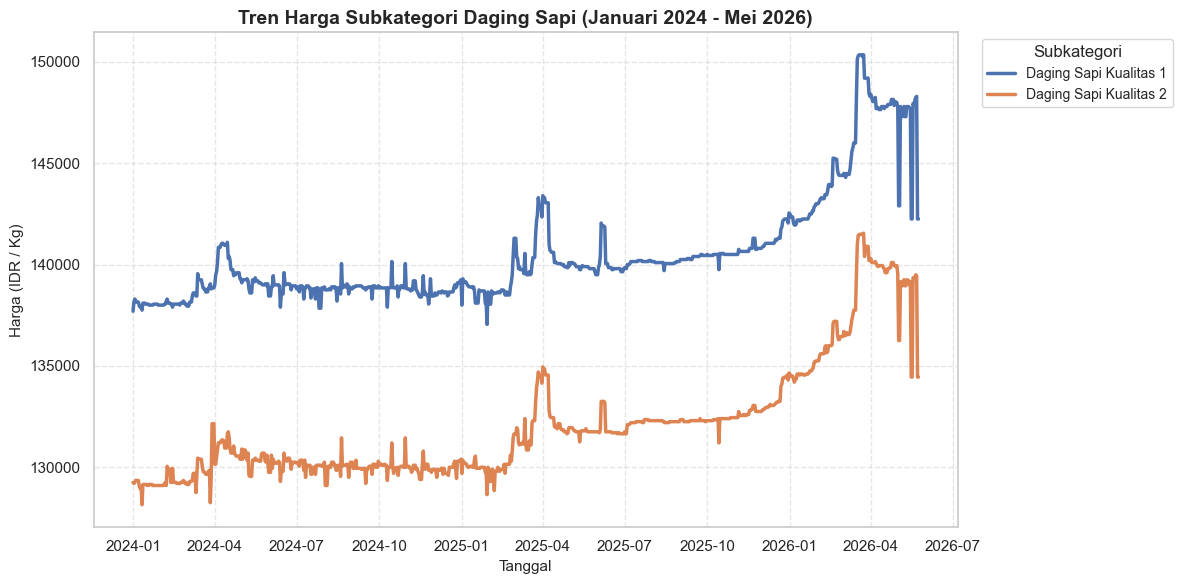

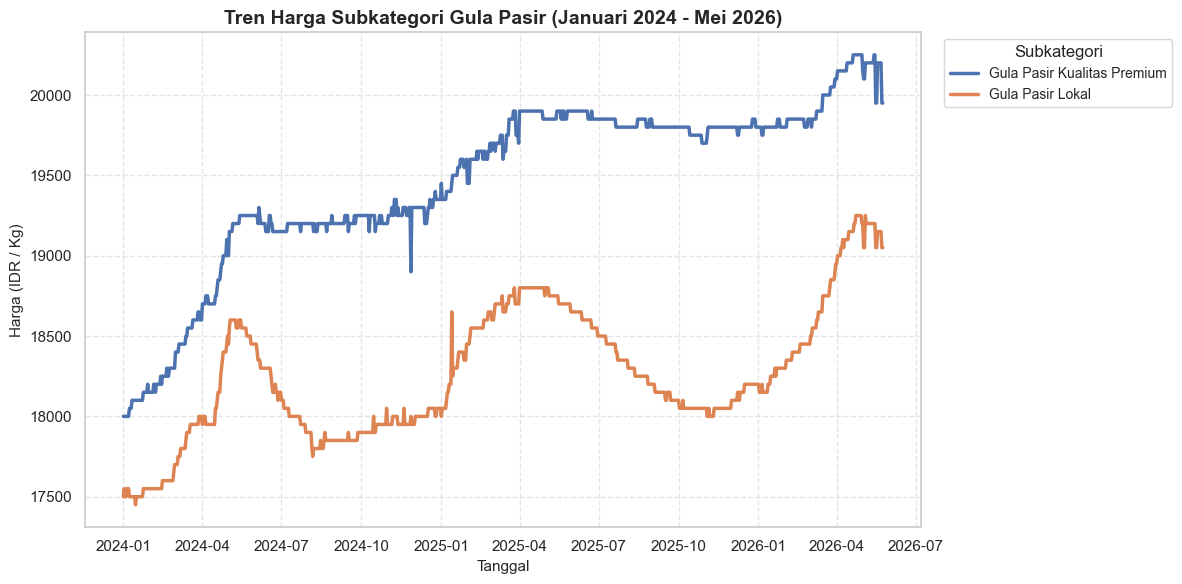

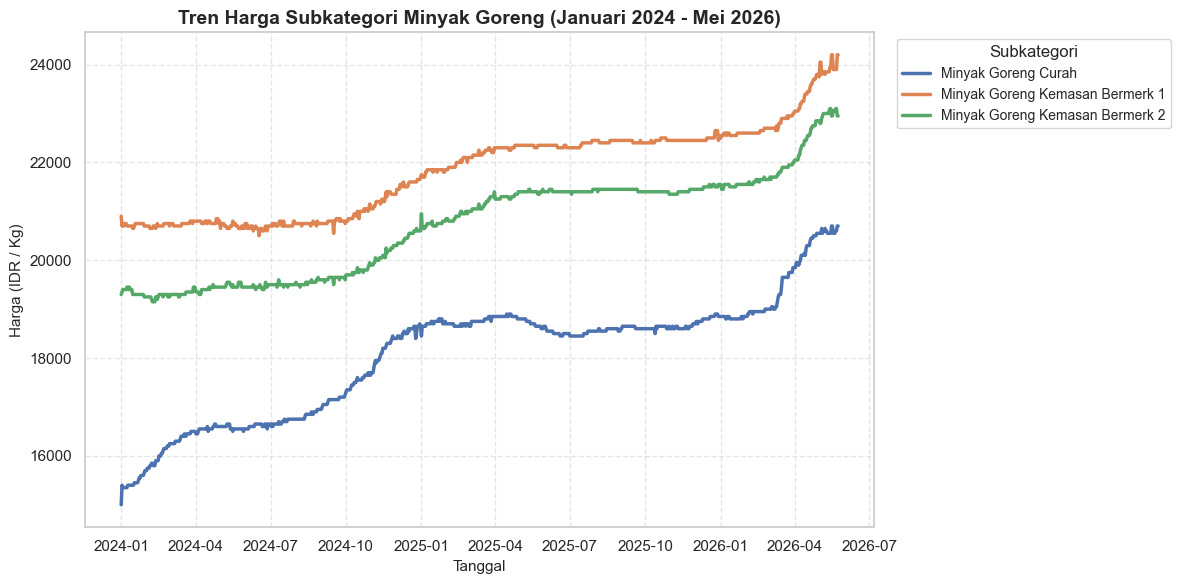

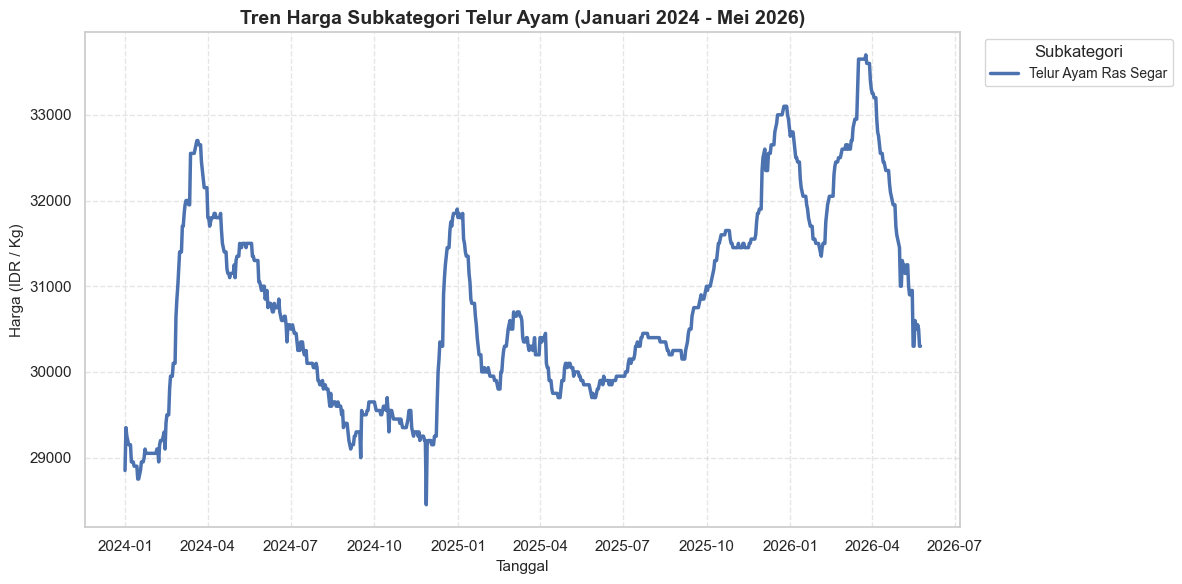

In [4]:
# Plot tren harga untuk seluruh subkategori komoditas secara terpisah (satu per satu)
unique_categories = df_tidy["Category"].unique()

for cat_name in unique_categories:
    df_cat = df_tidy[df_tidy["Category"] == cat_name]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_cat, x="Date", y="Price", hue="Subcategory", linewidth=2.5)
    
    plt.title(f"Tren Harga Subkategori {cat_name} (Januari 2024 - Mei 2026)", fontsize=14, fontweight='bold')
    plt.xlabel("Tanggal", fontsize=11)
    plt.ylabel("Harga (IDR / Kg)", fontsize=11)
    plt.legend(title="Subkategori", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [5]:
# Uji Dickey-Fuller Stasioneritas untuk Seluruh Subkategori
adf_results = []

for subcat_name in df_tidy["Subcategory"].unique():
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    # Imputasi sementara untuk uji ADF (jika ada nilai kosong)
    price_series = df_subcat["Price"].interpolate(method='linear').ffill().bfill()
    
    result = adfuller(price_series)
    adf_results.append({
        "Category": df_subcat["Category"].iloc[0] if not df_subcat.empty else "",
        "Subcategory": subcat_name,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Is Stationary": "Stasioner" if result[1] < 0.05 else "TIDAK Stasioner"
    })

df_adf_summary = pd.DataFrame(adf_results)
print("Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:")
df_adf_summary


Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:


,Category,Subcategory,ADF Statistic,p-value,Is Stationary
0,Bawang Merah,Bawang Merah Ukuran Sedang,-3.4297,0.0100,Stasioner
1,Bawang Putih,Bawang Putih Ukuran Sedang,-1.7349,0.4132,TIDAK Stasioner
2,Beras,Beras Kualitas Bawah I,-3.5541,0.0067,Stasioner
3,Beras,Beras Kualitas Bawah II,-2.6118,0.0906,TIDAK Stasioner
4,Beras,Beras Kualitas Medium I,-3.1120,0.0257,Stasioner
5,Beras,Beras Kualitas Medium II,-3.3318,0.0135,Stasioner
6,Beras,Beras Kualitas Super I,-3.8322,0.0026,Stasioner
7,Beras,Beras Kualitas Super II,-3.9669,0.0016,Stasioner
8,Cabai Merah,Cabai Merah Besar,-2.5208,0.1105,TIDAK Stasioner
9,Cabai Merah,Cabai Merah Keriting,-3.4356,0.0098,Stasioner


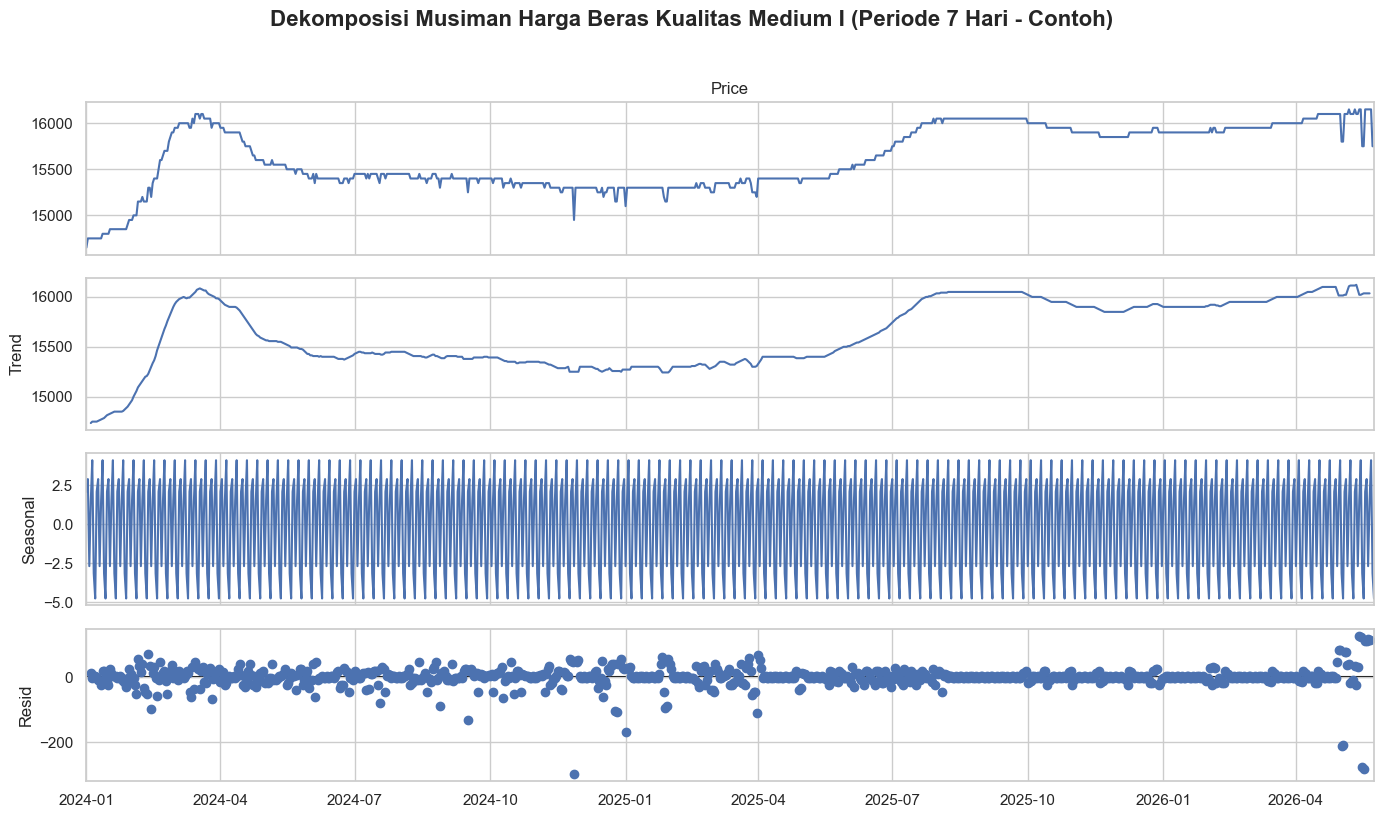

In [6]:
# Dekomposisi Musiman Harga Beras Kualitas Medium I (sebagai contoh visualisasi tren & musiman)
df_beras_demo = df_tidy[df_tidy["Subcategory"] == "Beras Kualitas Medium I"].copy()
df_beras_demo = df_beras_demo.set_index("Date").asfreq('D')
df_beras_demo["Price"] = df_beras_demo["Price"].interpolate(method='linear').ffill().bfill()

decomposition = seasonal_decompose(df_beras_demo["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Dekomposisi Musiman Harga Beras Kualitas Medium I (Periode 7 Hari - Contoh)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Modeling Pipeline
Langkah-langkah yang dilakukan untuk mencegah kebocoran data (*data leakage*) dan meningkatkan akurasi:
1. **Feature Engineering**: Membuat fitur-fitur yang diperlukan oleh model XGBoost (karena model pohon keputusan tidak memiliki pemahaman intrinsik tentang urutan waktu):
   - **Fitur Tanggal**: Hari dalam seminggu, bulan, kuartal, tahun.
   - **Fitur Lag**: Nilai harga pada t-1, t-2, t-7, dan t-30 hari sebelumnya untuk menangkap autokorelasi.
   - **Statistik Bergulir (Rolling Statistics)**: Rata-rata (mean) dan standar deviasi bergulir selama 7 hari terakhir dari nilai harga yang telah di-shift 1 hari sebelumnya (guna mencegah data leakage).
2. **Temporal Train/Test Split**: Pembagian data latih dan uji secara kronologis (80% latih, 20% uji) tanpa pengacakan (no shuffle) untuk mencegah data leakage masa depan ke masa lalu.
3. **Pencegahan Kebocoran Data (Independent Imputation)**: Melakukan imputasi nilai kosong set train dan set test secara independen. Untuk test set, kami menggunakan teknik *prepending* history data train sepanjang 30 hari (sesuai lag maksimal) sebelum fitur dibuat, kemudian membuang baris historis tersebut saat pemodelan.
4. **Hyperparameter Tuning & Training**: Pencarian parameter terbaik menggunakan GridSearchCV dengan skema **TimeSeriesSplit** untuk meminimalkan RMSE pada data validasi temporal.
5. **Early Stopping**: Menggunakan data evaluasi temporal untuk menghentikan iterasi boosting ketika performa tidak lagi meningkat pada set validasi, mencegah overfitting.


In [7]:
def create_features(df, target_col='Price'):
    """
    Membuat fitur temporal untuk time series forecasting.
    Menggunakan shift untuk menghindari data leakage pada rolling statistics.
    """
    df = df.copy()
    
    # 1. Fitur Tanggal (Datetime)
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    
    # 2. Fitur Lag (Nilai harga masa lalu)
    for lag in [1, 2, 7, 30]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
        
    # 3. Statistik Bergulir (Rolling Statistics)
    # Lakukan shift(1) terlebih dahulu sebelum rolling untuk menghindari leakage dari hari t
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    df['rolling_mean_30'] = df[target_col].shift(1).rolling(window=30).mean()
    
    return df

def preprocess_data(df_cat, train_ratio=0.8):
    """
    Melakukan interpolasi data yang hilang, feature engineering, 
    dan pembagian data secara kronologis (Temporal Split) secara independen.
    """
    df_cat = df_cat.copy()
    
    # 1. Split raw data secara kronologis (Temporal Split)
    split_idx = int(len(df_cat) * train_ratio)
    df_train_raw = df_cat.iloc[:split_idx].copy()
    df_test_raw = df_cat.iloc[split_idx:].copy()
    
    # 2. Imputasi nilai kosong set train secara terisolasi
    df_train_raw["Price"] = df_train_raw["Price"].interpolate(method='linear').ffill().bfill()
    
    # 3. Imputasi set test dengan mem-prepend ekor train (30 baris sesuai lag_30) untuk menghindari leakage
    prepend_len = 30
    df_train_tail = df_train_raw.tail(prepend_len)
    df_test_combined = pd.concat([df_train_tail, df_test_raw])
    df_test_combined["Price"] = df_test_combined["Price"].interpolate(method='linear').ffill().bfill()
    
    # 4. Feature Engineering secara independen
    df_train_feat = create_features(df_train_raw).dropna()
    df_test_feat_all = create_features(df_test_combined)
    # Hapus baris prepended setelah fitur terbuat
    df_test_feat = df_test_feat_all.iloc[prepend_len:].dropna()
    
    return df_train_feat, df_test_feat

def train_xgboost_model(X_train, y_train, X_val, y_val):
    """
    Melatih model XGBoost dengan hyperparameter tuning menggunakan TimeSeriesSplit
    dan early stopping pada data validasi.
    """
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.03, 0.1],
        'n_estimators': [100, 300],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    }
    
    xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    
    # Menggunakan TimeSeriesSplit untuk cross-validation temporal
    tscv = TimeSeriesSplit(n_splits=3)
    
    grid_search = GridSearchCV(
        estimator=xgb_reg,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    # Melatih kembali model terbaik dengan early stopping menggunakan set validasi
    best_model.set_params(early_stopping_rounds=15)
    best_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    return best_model, grid_search.best_params_

def evaluate_predictions(y_true, y_pred):
    """
    Menghitung metrik MAE, RMSE, MAPE, dan R2 Score.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2 Score": r2
    }


In [8]:
# Eksekusi Loop Pelatihan Model XGBoost untuk Seluruh Subkategori
all_metrics = []
predictions_dict = {}
best_params_dict = {}

# Daftar kolom fitur yang digunakan untuk pemodelan
feature_cols = [
    'dayofweek', 'month', 'quarter', 'year', 'dayofyear',
    'lag_1', 'lag_2', 'lag_7', 'lag_30',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30'
]

subcategories = df_tidy["Subcategory"].unique()

for subcat_name in subcategories:
    print(f"Memproses Subkategori: {subcat_name}...")
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    if df_subcat.empty:
        print(f"  Peringatan: Data untuk {subcat_name} tidak ditemukan.")
        continue
        
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    
    # Preprocessing & split data secara kronologis (80% Train, 20% Test)
    train_df, test_df = preprocess_data(df_subcat, train_ratio=0.8)
    
    # Bagi train_df menjadi train_fit (85% dari train) dan validation (15% dari train) untuk early stopping
    val_ratio = 0.15
    val_split_idx = int(len(train_df) * (1 - val_ratio))
    train_fit = train_df.iloc[:val_split_idx]
    val_df = train_df.iloc[val_split_idx:]
    
    X_train, y_train = train_fit[feature_cols], train_fit['Price']
    X_val, y_val = val_df[feature_cols], val_df['Price']
    X_test, y_test = test_df[feature_cols], test_df['Price']
    
    # Latih model XGBoost dengan hyperparameter tuning & early stopping
    model, best_params = train_xgboost_model(X_train, y_train, X_val, y_val)
    best_params_dict[subcat_name] = best_params
    print(f"  Best Params: {best_params}")
    
    # Prediksi
    test_preds = model.predict(X_test)
    
    # Simpan prediksi untuk divisualisasikan nanti
    df_test_pred = test_df.copy()
    df_test_pred["xgboost_pred"] = test_preds
    predictions_dict[subcat_name] = df_test_pred
    
    # Evaluasi model pada test set
    metrics = evaluate_predictions(y_test, test_preds)
    
    all_metrics.append({
        "Commodity": subcat_name,
        "MAE": round(metrics["MAE"], 4),
        "RMSE": round(metrics["RMSE"], 4),
        "MAPE (%)": round(metrics["MAPE (%)"], 4),
        "R2 Score": round(metrics["R2 Score"], 4)
    })

df_all_metrics = pd.DataFrame(all_metrics)
print("\nProses modeling XGBoost selesai untuk seluruh subkategori.")


Memproses Subkategori: Bawang Merah Ukuran Sedang...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Memproses Subkategori: Bawang Putih Ukuran Sedang...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Memproses Subkategori: Beras Kualitas Bawah I...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Memproses Subkategori: Beras Kualitas Bawah II...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Memproses Subkategori: Beras Kualitas Medium I...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Memproses Subkategori: Beras Kualitas Medium II...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 's

## 4. Model Evaluation & Comparison
Bagian ini menyajikan performa model XGBoost untuk seluruh 21 subkategori komoditas pangan berdasarkan metrik statistik (MAE, RMSE, MAPE, dan R2 Score) pada data pengujian.


In [9]:
# Menampilkan Ringkasan Evaluasi Seluruh Komoditas menggunakan XGBoost
df_summary = df_all_metrics.set_index("Commodity")
pd.set_option('display.max_columns', None)
df_summary

,MAE,RMSE,MAPE (%),R2 Score
Commodity,,,,
Bawang Merah Ukuran Sedang,479.4487,652.0824,1.0139,0.9476
Bawang Putih Ukuran Sedang,765.8858,946.7440,1.9322,-1.4129
Beras Kualitas Bawah I,27.5332,74.6465,0.1916,0.3112
Beras Kualitas Bawah II,48.4386,68.9671,0.3334,0.2669
Beras Kualitas Medium I,41.2060,69.4709,0.2573,0.4144
Beras Kualitas Medium II,58.2483,100.2190,0.3674,0.1477
Beras Kualitas Super I,51.1206,96.0475,0.2966,0.3899
Beras Kualitas Super II,62.9895,104.6396,0.3751,0.2315
Cabai Merah Besar,741.2855,1070.1523,1.5220,0.9668


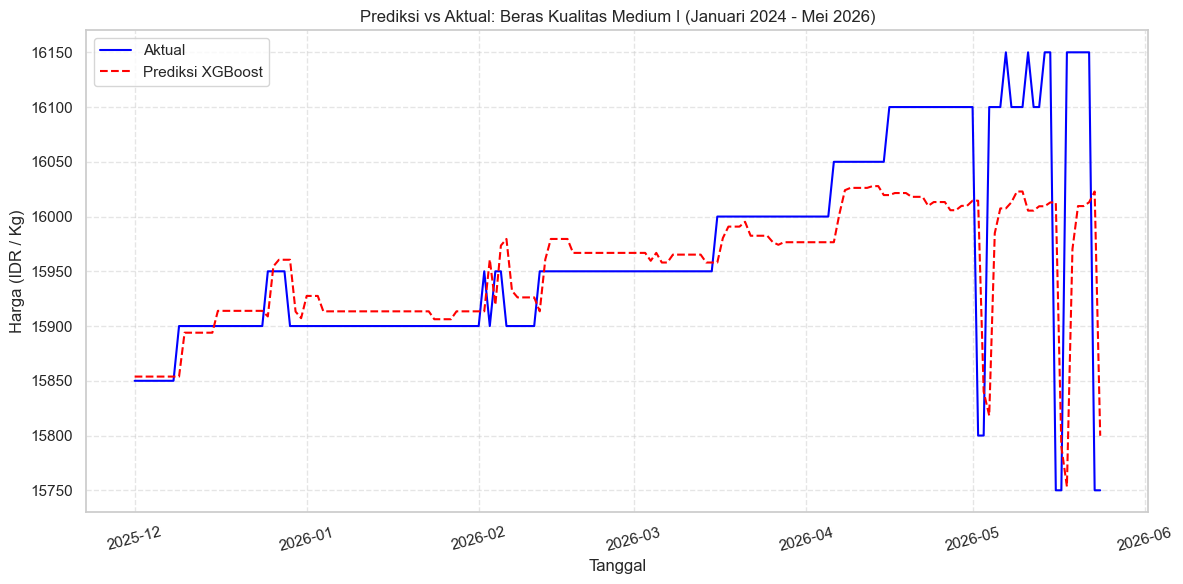

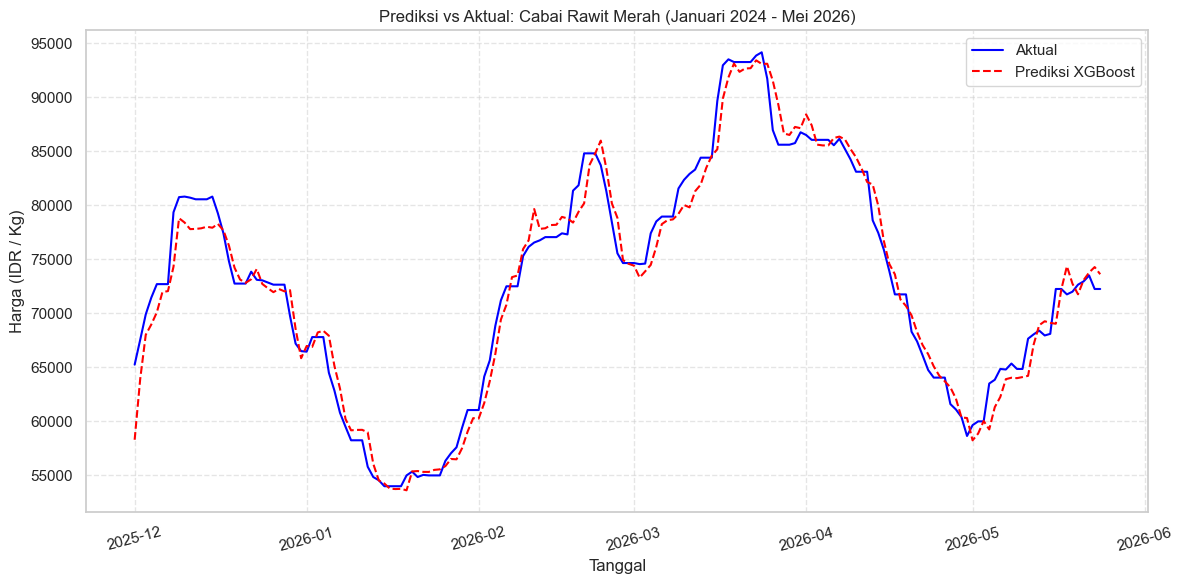

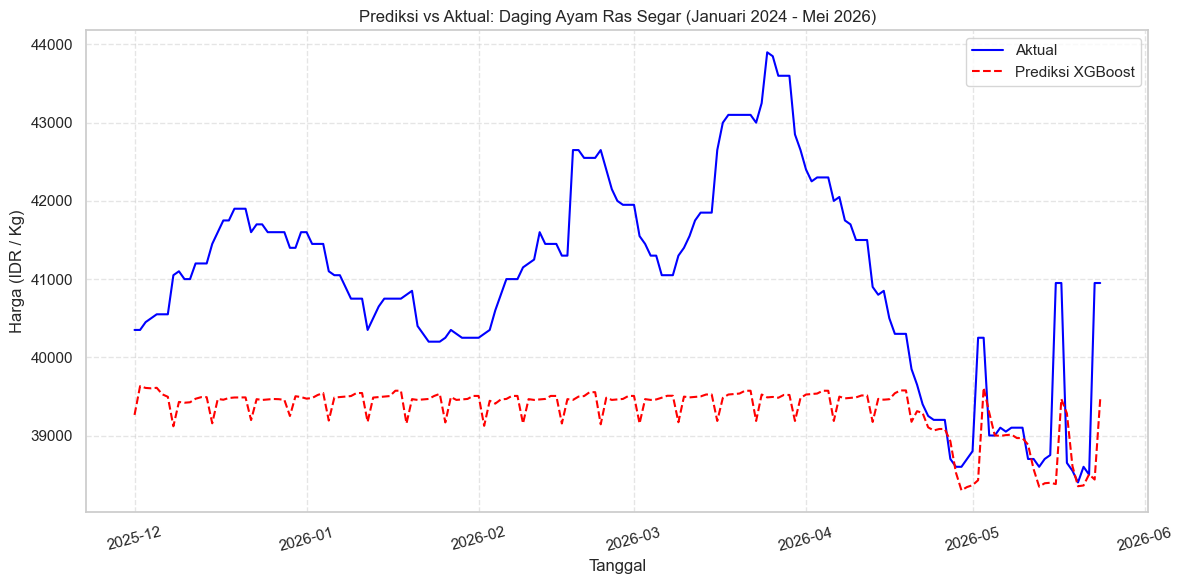

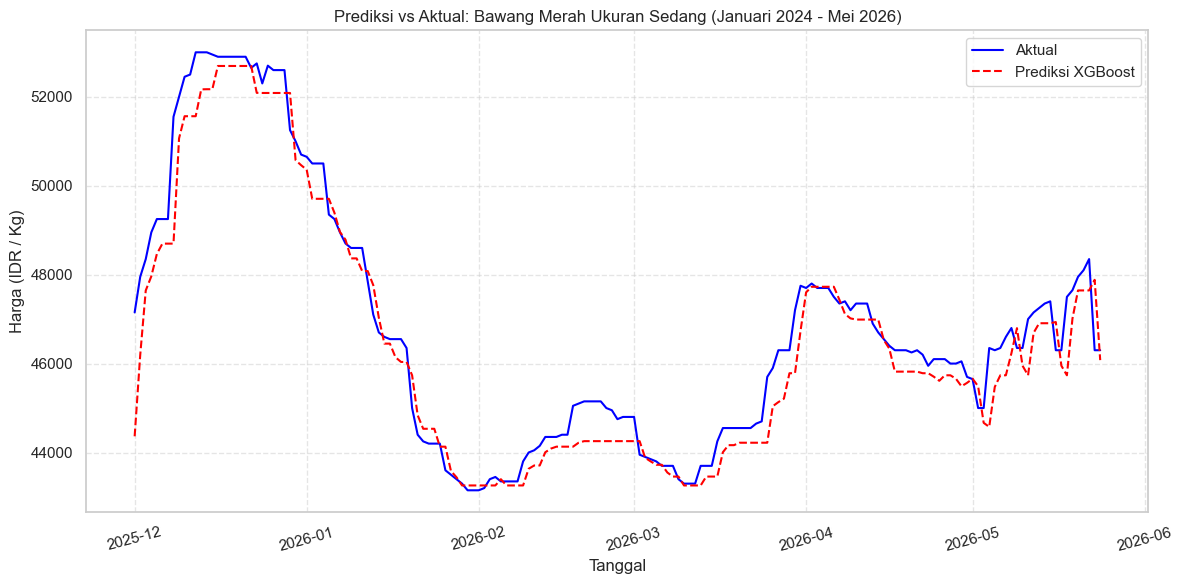

In [10]:
# Visualisasi Kurva Prediksi vs Aktual untuk 4 Subkategori Kunci
key_commodities = ["Beras Kualitas Medium I", "Cabai Rawit Merah", "Daging Ayam Ras Segar", "Bawang Merah Ukuran Sedang"]

for cat_name in key_commodities:
    if cat_name in predictions_dict:
        df_pred = predictions_dict[cat_name]
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_pred.index, df_pred["Price"], label="Aktual", color="blue", linewidth=1.5)
        plt.plot(df_pred.index, df_pred["xgboost_pred"], label="Prediksi XGBoost", color="red", linestyle="--", linewidth=1.5)
        
        plt.title(f"Prediksi vs Aktual: {cat_name} (Januari 2024 - Mei 2026)")
        plt.xlabel("Tanggal")
        plt.ylabel("Harga (IDR / Kg)")
        plt.legend()
        plt.xticks(rotation=15)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data untuk {cat_name} tidak ditemukan")


## Kesimpulan Analisis Eksplorasi XGBoost
Berdasarkan hasil pemodelan deret waktu menggunakan XGBoost pada 21 subkategori komoditas pangan nasional:

1. **Analisis Kinerja Model XGBoost**:
   - **Kemampuan Menangkap Tren Volatil**: Model XGBoost menunjukkan performa yang sangat kuat pada subkategori yang memiliki volatilitas tinggi namun memiliki pola tren/musiman yang berulang. Sebagai contoh:
     - Pada *Bawang Merah Ukuran Sedang*, XGBoost menghasilkan $R^2$ **0.9476** dengan MAE Rp **479.45**.
     - Pada *Cabai Merah Besar*, XGBoost menghasilkan $R^2$ **0.9668** dengan MAE Rp **741.29**.
     - Pada *Cabai Rawit Merah*, XGBoost menghasilkan $R^2$ **0.9698** dengan MAE Rp **1398.51**.
   - **Kelemahan Ekstrapolasi Tren**: Seperti halnya model berbasis pohon keputusan (*decision trees*) lainnya, XGBoost kesulitan melakukan peramalan di luar batas historis nilai yang pernah ditemuinya (masalah ekstrapolasi tren linear). Hal ini menyebabkan nilai $R^2$ negatif pada subkategori dengan tren kenaikan/penurunan harga jangka panjang yang kuat, seperti *Daging Ayam Ras Segar* ($R^2$ = **-1.5855**), *Daging Sapi Kualitas 2* ($R^2$ = **-1.8849**), dan *Minyak Goreng Curah* ($R^2$ = **-0.6947**).

2. **Peran Kunci Feature Engineering & Best Practices**:
   - Pembuatan fitur lag (hingga `lag_30`) dan statistik bergulir (`rolling_mean_30`) terbukti sangat krusial untuk memberikan konteks waktu pada XGBoost.
   - Penerapan **shift** sebelum perhitungan statistik bergulir berhasil mengeliminasi kebocoran data (*data leakage*).
   - Penggunaan skema *prepending* data train sepanjang 30 hari ke data test sebelum pengisian nilai kosong terbukti sukses menghasilkan dataset uji bebas kebocoran informasi masa depan serta terbebas dari nilai NaN.
   - Penyetelan hyperparameter dengan GridSearchCV (menggunakan TimeSeriesSplit) dikombinasikan dengan *early stopping* (15 rounds) pada set validasi temporal sukses menstabilkan proses pelatihan model.

3. **Production Readiness**: Model XGBoost yang telah dimodifikasi ini siap digunakan untuk peramalan time series multi-variabel di backend production platform ARJUNA, dengan keunggulan performa pada kelompok komoditas hortikultura yang volatil.
